Import required libraries

In [1]:
import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Add parent directory to sys.path
parent_path = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if parent_path not in sys.path:
    sys.path.append(parent_path)

# Import data processing and visualization functions from src/data_processing.py and src/visualization.py
from src.data_processing import load_csv
from src.visualization import visua_hist, visua_boxplot, visua_bar, visua_pie

Load data and display number of rows and columns

In [2]:
DATA_PATH = "../data/raw/BankChurners.csv"
data, header = load_csv(DATA_PATH)

print("Shape:", data.shape)
print("Header:", header)
print("First row:", data[0])

Shape: (10127, 23)
Header: ['"CLIENTNUM"', '"Attrition_Flag"', '"Customer_Age"', '"Gender"', '"Dependent_count"', '"Education_Level"', '"Marital_Status"', '"Income_Category"', '"Card_Category"', '"Months_on_book"', '"Total_Relationship_Count"', '"Months_Inactive_12_mon"', '"Contacts_Count_12_mon"', '"Credit_Limit"', '"Total_Revolving_Bal"', '"Avg_Open_To_Buy"', '"Total_Amt_Chng_Q4_Q1"', '"Total_Trans_Amt"', '"Total_Trans_Ct"', '"Total_Ct_Chng_Q4_Q1"', '"Avg_Utilization_Ratio"', '"Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1"', '"Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2"']
First row: ['768805383' '"Existing Customer"' '45' '"M"' '3' '"High School"'
 '"Married"' '"$60K - $80K"' '"Blue"' '39' '5' '1' '3' '12691' '777'
 '11914' '1.335' '1144' '42' '1.625' '0.061' '9.3448e-05' '0.99991']


➡️ **Observations**: 
- The data has 10,127 rows and 23 columns.
- Each row represents account information for a specific customer.

- Key features:
    - `CLIENTNUM`: Customer number (unique ID).
    - `Attrition_Flag`: Target variable (Existing Customer / Attrited Customer).
    - `Customer_Age`: Customer's age.
    - `Gender`: Gender.
    - `Dependent_count`: Number of dependents.
    - `Income_Category`: Annual income level.
    - `Card_Category`: Credit card type (Blue, Silver, Gold, Platinum).
    - `Credit_Limit`: Credit limit.
    - `Total_Trans_Amt`: Total transaction amount (in 12 months).
    - `Total_Trans_Ct`: Total number of transactions (in 12 months).
    - ...
- Columns with categorical data are: `Gender`, `Education_Level`, `Marital_Status`, `Income_Category`, `Card_Category`, `Attrition_Flag`.
- The features `Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1` and `Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2` are actually prediction results (probabilities) from another model (Naive Bayes) that was run previously on this dataset, so keeping them may cause risk (Overfitting).

Are there any missing values in the data columns?

In [3]:
# Since reading CSV file as strings, values have additional quotes ("")
missing_mask = (data == '') | (data == '"NaN"') | (data == '"nan"') | (data == '"?"') | (data == '"Unknown"')
missing_counts = np.sum(missing_mask, axis=0)
print("Number of missing value in each column:")
for col_name, count in zip(header, missing_counts):
    print(f"{col_name}: {count}")

Number of missing value in each column:
"CLIENTNUM": 0
"Attrition_Flag": 0
"Customer_Age": 0
"Gender": 0
"Dependent_count": 0
"Education_Level": 1519
"Marital_Status": 749
"Income_Category": 1112
"Card_Category": 0
"Months_on_book": 0
"Total_Relationship_Count": 0
"Months_Inactive_12_mon": 0
"Contacts_Count_12_mon": 0
"Credit_Limit": 0
"Total_Revolving_Bal": 0
"Avg_Open_To_Buy": 0
"Total_Amt_Chng_Q4_Q1": 0
"Total_Trans_Amt": 0
"Total_Trans_Ct": 0
"Total_Ct_Chng_Q4_Q1": 0
"Avg_Utilization_Ratio": 0
"Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1": 0
"Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2": 0


➡️ **Observations**: 
- The columns `Education_level`, `Marital_Status`, and `Income_category` have 'Unknown' values that need to be handled.

How many unique values does each categorical feature have?

In [4]:
print("Number of unique values in each column:")
for i in range(data.shape[1]):
    uni_i = np.unique(data[:, i])
    print(header[i], " - Count unique:", len(uni_i))

Number of unique values in each column:
"CLIENTNUM"  - Count unique: 10127
"Attrition_Flag"  - Count unique: 2
"Customer_Age"  - Count unique: 45
"Gender"  - Count unique: 2
"Dependent_count"  - Count unique: 6
"Education_Level"  - Count unique: 7
"Marital_Status"  - Count unique: 4
"Income_Category"  - Count unique: 6
"Card_Category"  - Count unique: 4
"Months_on_book"  - Count unique: 44
"Total_Relationship_Count"  - Count unique: 6
"Months_Inactive_12_mon"  - Count unique: 7
"Contacts_Count_12_mon"  - Count unique: 7
"Credit_Limit"  - Count unique: 6205
"Total_Revolving_Bal"  - Count unique: 1974
"Avg_Open_To_Buy"  - Count unique: 6813
"Total_Amt_Chng_Q4_Q1"  - Count unique: 1158
"Total_Trans_Amt"  - Count unique: 5033
"Total_Trans_Ct"  - Count unique: 126
"Total_Ct_Chng_Q4_Q1"  - Count unique: 830
"Avg_Utilization_Ratio"  - Count unique: 964
"Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1"  - Count 

➡️ **Observations**: 
- The `CLIENTNUM` column only serves as a customer identifier, with each customer having a different ID since the number of unique values equals the number of data rows → no duplicate rows. Including it as input may negatively impact performance since it's a random number string.
- Besides numerical columns, categorical data columns have relatively few unique values.

How is customer Age distributed?

Normal statistics of Customer_Age:
Mean: 46.32596030413745
Median: 46.0
Std Dev: 8.01641820891176
Min: 26
Max: 73


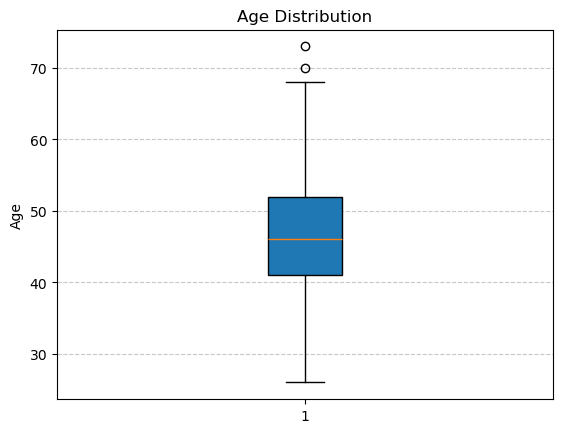

In [5]:
Customer_Age = data[:,2].astype(int)
print("Normal statistics of Customer_Age:")
print("Mean:", np.mean(Customer_Age))
print("Median:", np.median(Customer_Age))
print("Std Dev:", np.std(Customer_Age))
print("Min:", np.min(Customer_Age))
print("Max:", np.max(Customer_Age))
visua_boxplot(Customer_Age, "Age Distribution", "", "Age")

➡️ **Observations**: 
- There are a few older customers (around 70-73 years old) considered outliers compared to the majority in the dataset.
- The distribution is very balanced (Symmetric): This is the most important point. The mean ($\approx$ 46.33) and median (46.0) are almost equal.
- The customer base tends to concentrate strongly in the middle-aged range, with $50\%$ of customers falling within the 41-52 age range.

What is the frequency distribution of categorical values in the `Education_Level` column?

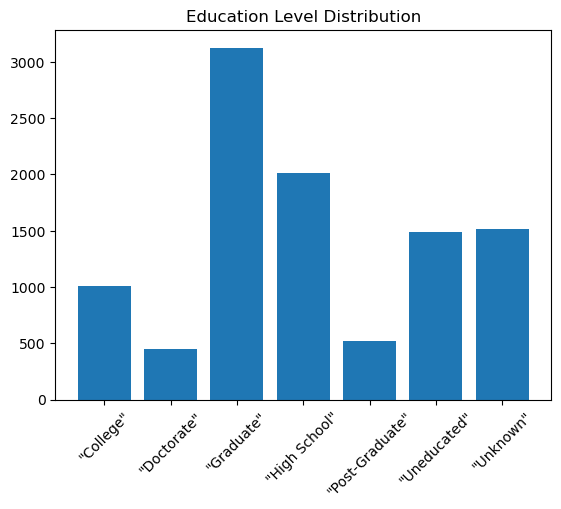

In [6]:
# Education Level
edu_idx = header.index('"Education_Level"')
unique_edu, edu_counts = np.unique(data[:, edu_idx], return_counts=True)

visua_bar(unique_edu, edu_counts, "Education Level Distribution")

➡️ **Observations**: 
- The "Graduate" education level (college graduates) has the highest frequency, indicating that the majority of customers are graduates.
- The data distribution is uneven, with the "Graduate" group having the largest number by far, with about 3,100 customers, while
"Doctorate" has the smallest proportion with only 500 customers.
- The "High School" group ranks second (around 2,000).
- Having a significant number (around 1,500) in the "Unknown" group is quite normal, possibly due to customers not wanting to provide information.

What is the ratio of customers who have left (`Attrited Customer`) versus those who remain (`Existing Customer`)?

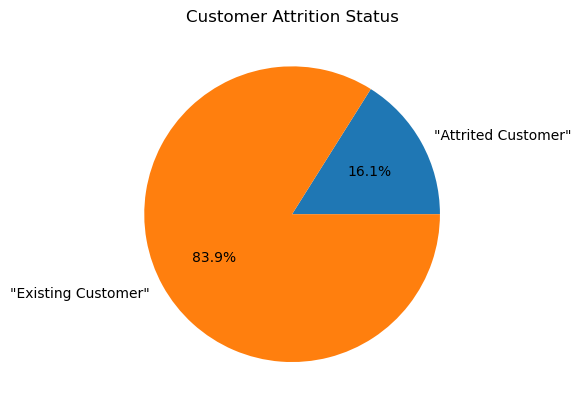

In [7]:
# Analyze Attrition_Flag feature
attr_idx = header.index('"Attrition_Flag"')
unique_attr, attr_counts = np.unique(data[:, attr_idx], return_counts=True)

visua_pie(attr_counts, unique_attr, "Customer Attrition Status")

➡️ **Observations**: 
- The number of churned customers with "Attrited Customer" value accounts for $16.1\%$ compared to customers who remain "Existing Customer" at $83.9\%$.
- The data is imbalanced, so when training the model, we should not use accuracy (`Accuracy`) as the sole metric but should add other metrics like `Precision`, `Recall`, etc.
- If not handled properly, the model will tend to predict everything as `Existing` to achieve high accuracy but fail to detect churned customers (Accuracy Paradox problem).

How is the `Credit_Limit` distributed?

Normal statistics of Credit_Limit:
Mean: 8631.953698034955
Median: 4549.0
Std Dev: 9088.327899308213
Min: 1438.3
Max: 34516.0


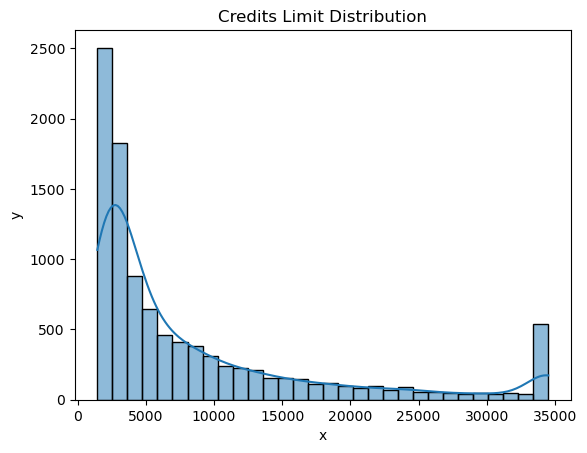

In [8]:
Credit_idx = header.index('"Credit_Limit"')
data_Credit = data[:, Credit_idx].astype(float)
print("Normal statistics of Credit_Limit:")
print("Mean:", np.mean(data_Credit))
print("Median:", np.median(data_Credit))
print("Std Dev:", np.std(data_Credit))
print("Min:", np.min(data_Credit))
print("Max:", np.max(data_Credit))
visua_hist(data_Credit, "Credits Limit Distribution", "x", "y")

➡️ **Observations**: 
- The majority of customers have low credit limits (concentrated at levels below 5,000). Customers with "huge" credit limits are in the minority, but their values are so large that they have pulled the mean up.
- The histogram is Heavily Right-Skewed.
    - Mean ($8,631$) > Median ($4,549$): The mean value is almost double the median. This shows that the tail of the histogram extends toward large values (to the right).